# SUPERVISED REGRESSION 

In [13]:
%pip install tensorflow
%pip install numpy
%pip install matplotlib
%pip install Pillow



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



### IMPORTING NECESSARY LIBRARIES

In [14]:
import numpy as np
import PIL.Image as Image
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models


In [15]:
# Image size set to 50 for 50x50 pixels
IMG_SIZE=50

### DATASET GENERATION FUNCTION 
To create array of zeros in grayscale with img size 50*50 and randomly assign pixel values to 255

In [16]:
def dataset_generator(num_samples, img_size=IMG_SIZE):
    try:
        img=np.zeros((num_samples,img_size,img_size,1),dtype=np.float32)
        coordinates = np.zeros((num_samples, 2), dtype=np.float32)
        for i in range(num_samples):
            x=np.random.randint(0, img_size)
            y=np.random.randint(0, img_size)  
            img[i,y,x,0]=255.0
            coordinates[i] = [x / (img_size - 1), y / (img_size - 1)]
        return img, coordinates
    except:
        print("Error in dataset generation")
        return None, None




Creating Training and Testing datasets using the data generator function


In [17]:
# 10000 samples generated for train set to have plenty of training data the model can make multiple passes of
# 2000  new samples generated for test set 

X_train, y_train = dataset_generator(10000, IMG_SIZE)
X_test, y_test = dataset_generator(2000, IMG_SIZE) 

### MODEL CREATION

In [18]:
model = models.Sequential([
    # Input Layer according to image size and 1 channel (grayscale)
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    # First Convolutional Layer with a filter size of 3x3, 16 filters, ReLU activation, and same padding
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # Second Convolutional Layer with a filter size of 3x3, 32 filters, ReLU activation, and same padding
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # Flatten converts 2D maps to 1D vectors for the Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='sigmoid') 
])



Model Compilation

In [19]:
# Compile using MSE for regression distance and Adam adaptive learning rate optimizer
model.compile(optimizer='adam', loss='mse', metrics=['mae'])



MODEL TRAINING

In [20]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0298 - mae: 0.1103 - val_loss: 8.6258e-04 - val_mae: 0.0230
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.6127e-04 - mae: 0.0162 - val_loss: 2.9610e-04 - val_mae: 0.0132
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.1252e-04 - mae: 0.0107 - val_loss: 2.2162e-04 - val_mae: 0.0108
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.6006e-04 - mae: 0.0092 - val_loss: 1.5753e-04 - val_mae: 0.0093
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.4307e-04 - mae: 0.0087 - val_loss: 1.4899e-04 - val_mae: 0.0089
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.4363e-04 - mae: 0.0087 - val_loss: 1.6950e-04 - val_mae: 0.0096
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.3296e-04 - mae: 0.0085 - val_loss: 1.5002e-04 - val_mae: 0.0088
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.2507e-04 - mae: 0.0083 - val_loss: 1.3064e-04 - val_mae: 0.0

Mean Absolute Error and Average Pixel error calculated

In [21]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
pixel_error = test_mae * (IMG_SIZE - 1)

print(f"Mean Absolute Error (Normalized): {test_mae:.4f}")
print(f"Average Error in Pixels: {pixel_error:.2f} pixels")

Mean Absolute Error (Normalized): 0.0034
Average Error in Pixels: 0.17 pixels


Visualisation of Ground truth vs Model Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted (7.06, 18.92) and Truth (7.00, 19.00) in sample 0 
Predicted (44.78, 12.79) and Truth (45.00, 13.00) in sample 1 
Predicted (18.21, 30.93) and Truth (18.00, 31.00) in sample 2 
Predicted (19.14, 19.29) and Truth (19.00, 19.00) in sample 3 
Predicted (32.38, 0.20) and Truth (31.00, 0.00) in sample 4 


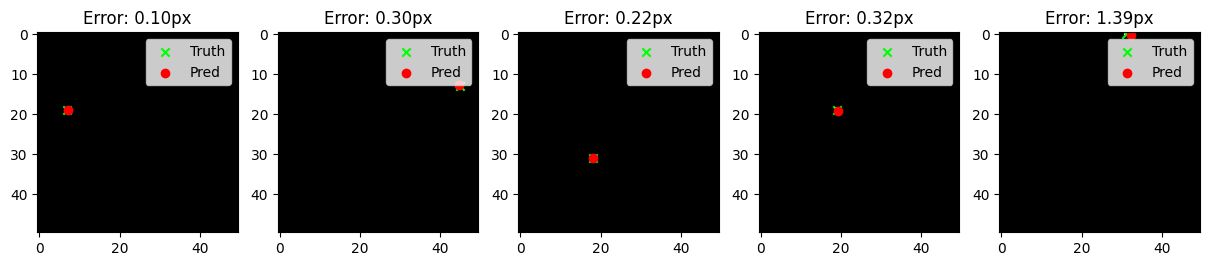

In [24]:
# First 5 samples from test set selected
samples = X_test[:5]
true_coords = y_test[:5]
# Predictions made on these samples
preds = model.predict(samples)

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Reshape the 4D tensor to 2D for visualization
    plt.imshow(samples[i].reshape(IMG_SIZE, IMG_SIZE),cmap='gray')
    # De-normalize coordinates to pixel values
    tx, ty = true_coords[i] * (IMG_SIZE - 1)
    px, py = preds[i] * (IMG_SIZE - 1)
    # Overlay the Ground Truth and Model Prediction in same plot
    plt.scatter(tx, ty, color='lime', marker='x', label='Truth')
    plt.scatter(px, py, color='red', marker='o', label='Pred')
    # Calculate Euclidean distance to measure error
    plt.title(f"Error: {np.sqrt((tx-px)**2 + (ty-py)**2):.2f}px")
    plt.legend()
    print(f"Predicted ({px:.2f}, {py:.2f}) and Truth ({tx:.2f}, {ty:.2f}) in sample {i} ")

plt.show()



Training and validation loss plot

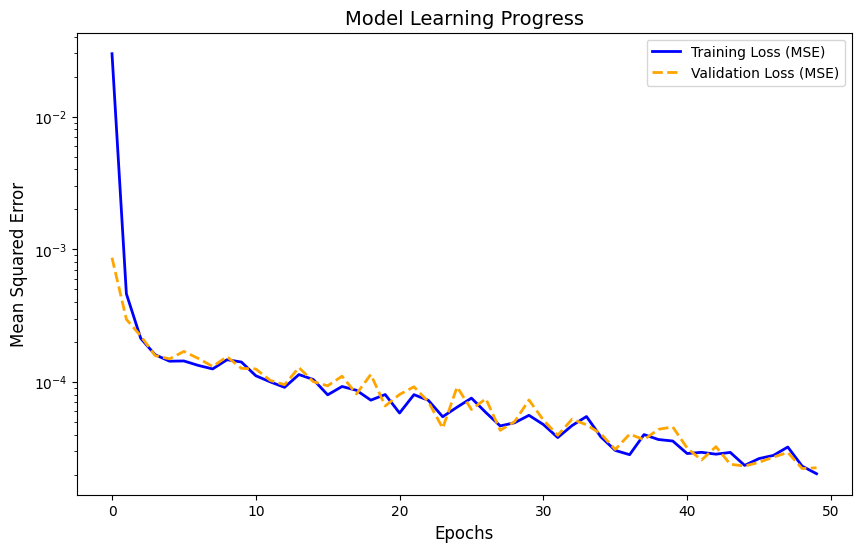

In [23]:
plt.figure(figsize=(10, 6))
# Plot training and validation loss to check convergence
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange', linestyle='--', linewidth=2)

plt.yscale('log')

plt.title('Model Learning Progress', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)

plt.legend()
plt.show()